# Student Grade Prediction

Utilising various models from SKL to explore how course deliveries and attendance impact the final grade

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Create dataframe
#Download the csv from Moodle and upload to Colab's session storage
df = pd.read_csv('MP2_Data.csv')

Pre-processing

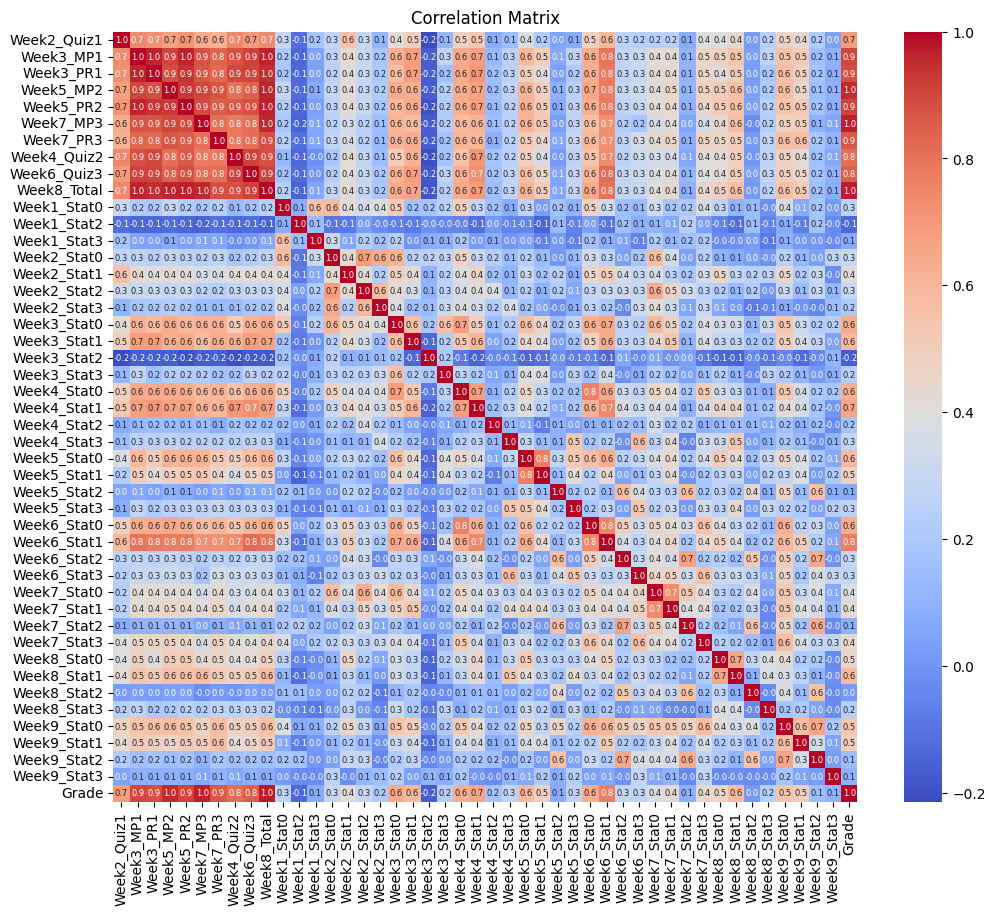

<Figure size 640x480 with 0 Axes>

In [ ]:
#Drop unnecessary columns as they have low variance (0) or are unnecessary
data_cleaned = df.drop(columns=['ID', 'Week1_Stat1'])

#Calculate the correlation matrix
correlation_matrix = data_cleaned.corr()

#Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, annot_kws={"size":6}, cmap='coolwarm', fmt=".1f")
plt.title('Correlation Matrix')
plt.show()
plt.savefig('correlation_matrix.png')

#Separate features and target (Grade)
X = data_cleaned.drop(columns=['Grade'])
y = data_cleaned['Grade']

#Find highly correlated features (correlation > 0.9) and lowly correlated features (correlation < 0.4)
high_corr_features = correlation_matrix.index[correlation_matrix['Grade'] > 0.9]
low_corr_features = correlation_matrix.index[correlation_matrix['Grade'] < 0.4]

#Remove both highly and lowly correlated features, but leave 'Grade' for later use
X_reduced_final = data_cleaned.drop(columns=high_corr_features.union(low_corr_features).difference(['Grade']))
#X_reduced_final2 = X_reduced_final.drop(columns=['Week3_MP1','Week3_PR1','Week5_MP2','Week5_PR2','Week7_MP3','Week7_PR3'])


Training and prediction

In [ ]:
#Split the reduced data into train and test sets
#Consider changing the random state to the same you used in your own project for
#a better model comparison
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_reduced_final.drop(columns=['Grade']), y, test_size=0.2, random_state=2)

# Initialize the scaler
scaler = StandardScaler()

#Initialize LR and RF models
#Again, consider changing the random state to the same you used
linear_model_final = LinearRegression()
random_forest_model_final = RandomForestRegressor(random_state=2)

#Train the models
linear_model_final.fit(X_train_final, y_train_final)
random_forest_model_final.fit(X_train_final, y_train_final)

#Model prediction
y_pred_linear_final = linear_model_final.predict(X_test_final)
y_pred_rf_final = random_forest_model_final.predict(X_test_final)

In [ ]:
# #Training and prediction
#Split the reduced data into train and test sets
#Consider changing the random state to the same you used in your own project for
#a better model comparison
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_reduced_final.drop(columns=['Grade']), y, test_size=0.2, random_state=2)

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

#Initialize LR and RF models
#Again, consider changing the random state to the same you used
linear_model_final = LinearRegression()
random_forest_model_final = RandomForestRegressor(random_state=2)

#Train the models
linear_model_final.fit(X_train_scaled, y_train_final)
random_forest_model_final.fit(X_train_scaled, y_train_final)

#Model prediction
y_pred_linear_final = linear_model_final.predict(X_test_scaled)
y_pred_rf_final = random_forest_model_final.predict(X_test_scaled)

Model evaluation

In [ ]:
#Evaluation
linear_mse_final = mean_squared_error(y_test_final, y_pred_linear_final)
linear_r2_final = r2_score(y_test_final, y_pred_linear_final)
rf_mse_final = mean_squared_error(y_test_final, y_pred_rf_final)
rf_r2_final = r2_score(y_test_final, y_pred_rf_final)

#Output the evaluation results
print(f"Linear Regression MSE: {linear_mse_final}, R2: {linear_r2_final}")
print(f"Random Forest MSE: {rf_mse_final}, R2: {rf_r2_final}")

Linear Regression MSE: 0.5981605384759351, R2: 0.8392505826638798
Random Forest MSE: 0.5563090909090909, R2: 0.8504977234869517


Visualisation

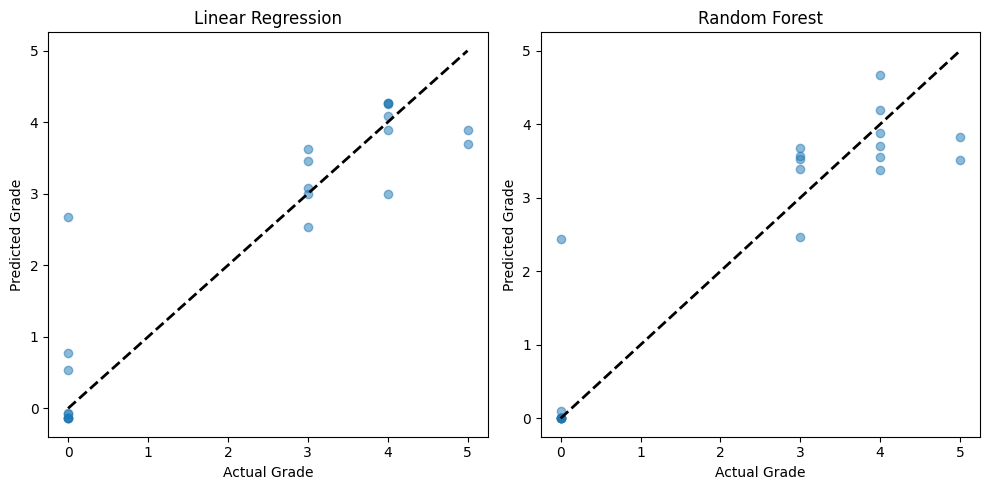

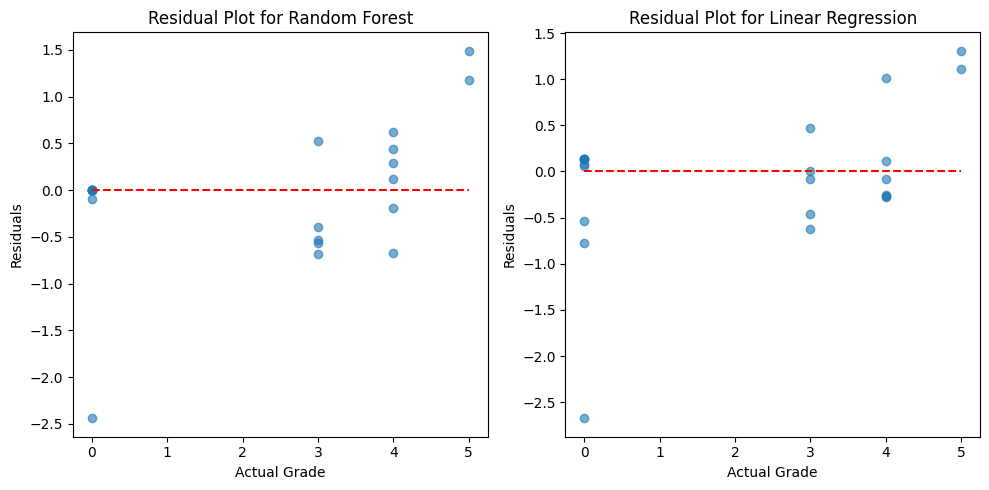

In [ ]:
plt.figure(figsize=(10, 5))

#Visualise the performance of LR
plt.subplot(1, 2, 1)
plt.scatter(y_test_final, y_pred_linear_final, alpha=0.5)
plt.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'k--', lw=2)
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title('Linear Regression')

#Visualise the performance of RF
plt.subplot(1, 2, 2)
plt.scatter(y_test_final, y_pred_rf_final, alpha=0.5)
plt.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'k--', lw=2)
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title('Random Forest')

plt.tight_layout()
plt.show()

#Calculate residuals
residuals_rf = y_test_final - y_pred_rf_final
residuals_linear = y_test_final - y_pred_linear_final

plt.figure(figsize=(10, 5))

#Create residual plots
plt.subplot(1, 2, 1)
plt.scatter(y_test_final, residuals_rf, alpha=0.6)
plt.hlines(y=0, xmin=min(y_test_final), xmax=max(y_test_final), colors='r', linestyles='dashed')
plt.xlabel('Actual Grade')
plt.ylabel('Residuals')
plt.title('Residual Plot for Random Forest')

plt.subplot(1, 2, 2)
plt.scatter(y_test_final, residuals_linear, alpha=0.6)
plt.hlines(y=0, xmin=min(y_test_final), xmax=max(y_test_final), colors='r', linestyles='dashed')
plt.xlabel('Actual Grade')
plt.ylabel('Residuals')
plt.title('Residual Plot for Linear Regression')
plt.tight_layout()
plt.show()